# Student Academic Performance: What Actually Drives Exam Scores?
### Jupyter Notebook Data Analysis Project — Advanced Level

**Author:** Kartik Parashar
**Dataset:** `student_performance.csv` — dataset of 1,500+ students with lifestyle, behavioral, and academic features.

## 1. Objective

I wanted to look into what actually separates high-scoring students from the rest — is it just studying more, or do things like sleep, screen time, and outside support (tutoring, family background) matter just as much? This notebook walks through that step by step:
- Explore the dataset and understand what factors are recorded
- Clean the data (missing values, duplicates, and outliers)
- Narrow down to one focused research question based on what the exploration shows
- Use visualizations to answer that question and pull out practical takeaways for students, parents, and teachers

The dataset covers daily habits (study hours, sleep, social media use), support factors (tutoring, parental education, internet access), and outcomes (previous score, final exam score) for each student.


## 2. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 3. Loading the Dataset

In [2]:
df = pd.read_csv("student_performance.csv")
df.shape


(1515, 15)

In [3]:
df.head()


,student_id,age,gender,study_hours_per_day,sleep_hours_per_day,social_media_hours_per_day,attendance_pct,part_time_job,extracurricular,tutoring,parental_education,internet_access,stress_level,previous_score,exam_score
0,STU3410,16,Female,3.20,6.20,4.50,75.20,No,No,No,Masters,Yes,9.00,36.20,65.60
1,STU2016,17,Female,0.60,5.90,4.50,68.30,No,No,No,High School,Yes,5.00,57.70,51.40
2,STU3092,17,Female,4.90,6.80,5.50,85.10,No,No,No,High School,Yes,8.00,75.40,89.80
3,STU2783,15,Female,4.80,7.70,1.90,73.50,No,No,No,Bachelors,Yes,2.00,75.50,100.00
4,STU3145,18,Male,3.00,7.80,3.70,84.30,No,No,Yes,High School,No,5.00,86.10,88.10


**Column Reference**

| Column | Description |
|---|---|
| `student_id` | Unique student identifier |
| `age`, `gender` | Demographics |
| `study_hours_per_day` | Average daily study time (hours) |
| `sleep_hours_per_day` | Average daily sleep (hours) |
| `social_media_hours_per_day` | Average daily social media/screen time (hours) |
| `attendance_pct` | Class attendance percentage |
| `part_time_job` | Whether the student works part-time |
| `extracurricular` | Participation in extracurricular activities |
| `tutoring` | Whether the student receives extra tutoring |
| `parental_education` | Highest education level of parents |
| `internet_access` | Home internet access |
| `stress_level` | Self-reported stress (1–10 scale) |
| `previous_score` | Score on the prior exam/term |
| `exam_score` | Final exam score (target variable, 0–100) |


## 4. Exploratory Data Analysis (EDA)

### 4.1 Structure & Data Types


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1515 non-null   str    
 1   age                         1515 non-null   int64  
 2   gender                      1515 non-null   str    
 3   study_hours_per_day         1515 non-null   float64
 4   sleep_hours_per_day         1470 non-null   float64
 5   social_media_hours_per_day  1515 non-null   float64
 6   attendance_pct              1515 non-null   float64
 7   part_time_job               1515 non-null   str    
 8   extracurricular             1515 non-null   str    
 9   tutoring                    1515 non-null   str    
 10  parental_education          1494 non-null   str    
 11  internet_access             1515 non-null   str    
 12  stress_level                1515 non-null   float64
 13  previous_score              1515 non-null   

### 4.2 Summary Statistics

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,"1,515.00",16.49,1.13,15.00,15.00,17.00,17.50,18.00
study_hours_per_day,"1,515.00",3.56,2.00,0.00,2.50,3.50,4.50,29.45
sleep_hours_per_day,"1,470.00",6.78,1.18,3.00,6.10,6.80,7.60,10.00
social_media_hours_per_day,"1,515.00",3.19,1.55,0.00,2.10,3.20,4.30,8.10
attendance_pct,"1,515.00",84.71,9.38,52.60,78.30,84.90,91.60,100.00
stress_level,"1,515.00",5.60,1.94,1.00,4.00,6.00,7.00,10.00
previous_score,"1,515.00",67.92,11.75,30.70,60.00,67.90,75.90,100.00
exam_score,"1,515.00",80.54,11.48,39.70,72.40,81.20,88.95,100.00


### 4.3 Missing Values

In [6]:
missing = df.isnull().sum()
missing[missing > 0]


sleep_hours_per_day    45
parental_education     21
dtype: int64

### 4.4 Duplicate Records

In [7]:
dupe_count = df.duplicated(subset=["student_id"]).sum()
print(f"Duplicate students found: {dupe_count}")


Duplicate students found: 15


### 4.5 Outlier Detection — Study Hours

Some recorded `study_hours_per_day` values exceed 20+ hours/day, which is physically implausible and signals data-entry errors rather than genuine behavior.


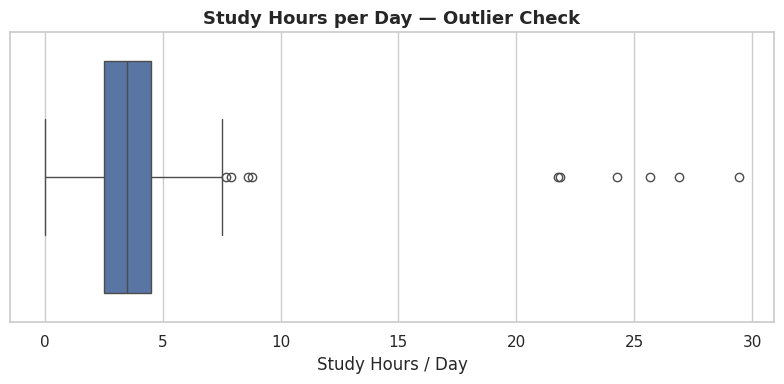

Students reporting >12 study hours/day: 6


In [8]:
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(x=df["study_hours_per_day"], ax=ax, color="#4C72B0")
ax.set_title("Study Hours per Day — Outlier Check")
ax.set_xlabel("Study Hours / Day")
plt.tight_layout()
plt.show()

print(f"Students reporting >12 study hours/day: {(df['study_hours_per_day'] > 12).sum()}")


## 5. Data Cleaning

Based on the EDA above:

1. **Missing `sleep_hours_per_day`** — imputed with the overall median (a stable, typical value; sleep patterns don't vary systematically enough by other columns here to justify group-wise imputation).
2. **Missing `parental_education`** — filled as `"Not Reported"` rather than guessed, since this is categorical and imputing a specific education level would fabricate information.
3. **Duplicate student records** — dropped.
4. **Implausible study-hour outliers (>12 hrs/day)** — removed, since 20–30 hours/day is impossible and would distort the study-hours vs. score relationship.


In [9]:
df_clean = df.copy()

# sleep hours - just fill with the median, nothing fancy needed here
df_clean["sleep_hours_per_day"] = df_clean["sleep_hours_per_day"].fillna(
    df_clean["sleep_hours_per_day"].median()
)

# parental education is categorical, so don't guess a value - just label it
df_clean["parental_education"] = df_clean["parental_education"].fillna("Not Reported")

# get rid of the duplicate student rows we found earlier
df_clean = df_clean.drop_duplicates(subset=["student_id"])

# and drop the impossible study-hour entries (20-30 hrs/day isn't real)
df_clean = df_clean[df_clean["study_hours_per_day"] <= 12]

print(f"Rows before cleaning: {len(df)} -> Rows after cleaning: {len(df_clean)}")
df_clean.isnull().sum().sum(), df_clean.duplicated().sum()


Rows before cleaning: 1515 -> Rows after cleaning: 1494


(np.int64(0), np.int64(0))

## 6. Research Question

After going through the EDA, the columns that stood out the most were the daily habits (study, sleep, screen time) and the support-related ones (tutoring, parental education). That led me to settle on one question to actually dig into:

> **"Which daily habits and support factors most strongly influence exam performance, and what realistic changes would help a lower-performing student the most?"**

The rest of the notebook works through this - starting broad with correlations, then narrowing in on specific comparisons like tutoring and study-hour thresholds.


## 7. Visualization & Insights

### 7.1 Correlation Heatmap — Numeric Features vs. Exam Score

A correlation heatmap gives a fast overview of which numeric habits move together with exam performance.


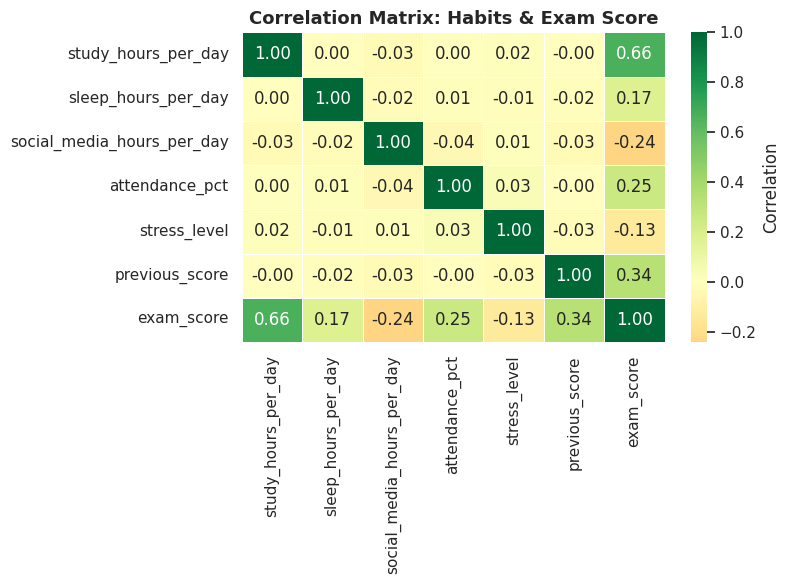

In [10]:
numeric_cols = ["study_hours_per_day", "sleep_hours_per_day", "social_media_hours_per_day",
                 "attendance_pct", "stress_level", "previous_score", "exam_score"]
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Matrix: Habits & Exam Score")
plt.tight_layout()
plt.show()


`previous_score` and `study_hours_per_day` come out with the strongest positive correlation to `exam_score`, while `social_media_hours_per_day` and `stress_level` lean negative. Not surprising directionally, but nice to have it actually quantified instead of assumed.


### 7.2 Study Hours vs. Exam Score

A scatter plot with a fitted trend line shows not just correlation direction but the practical magnitude — roughly how many points an extra hour of study is worth.


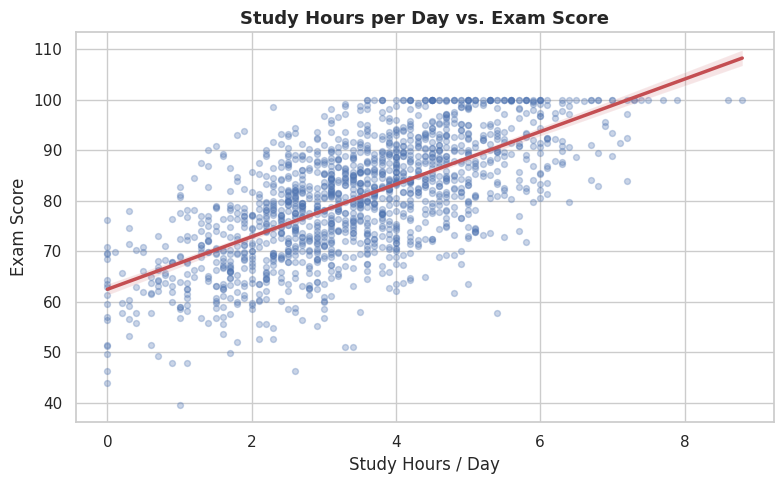

Approx. exam score gain per additional study hour/day: 5.20 points


In [11]:
fig, ax = plt.subplots(figsize=(8,5))
sns.regplot(data=df_clean, x="study_hours_per_day", y="exam_score",
            scatter_kws={"alpha":0.3, "s":18, "color":"#4C72B0"},
            line_kws={"color":"#C44E52", "linewidth":2.5}, ax=ax)
ax.set_title("Study Hours per Day vs. Exam Score")
ax.set_xlabel("Study Hours / Day")
ax.set_ylabel("Exam Score")
plt.tight_layout()
plt.show()

slope = np.polyfit(df_clean["study_hours_per_day"], df_clean["exam_score"], 1)[0]
print(f"Approx. exam score gain per additional study hour/day: {slope:.2f} points")


### 7.3 Sleep Duration Bands vs. Average Exam Score

Grouping students into sleep-duration bands checks for a threshold effect — is there a sleep range beyond which performance actually improves, or does more sleep only help up to a point?


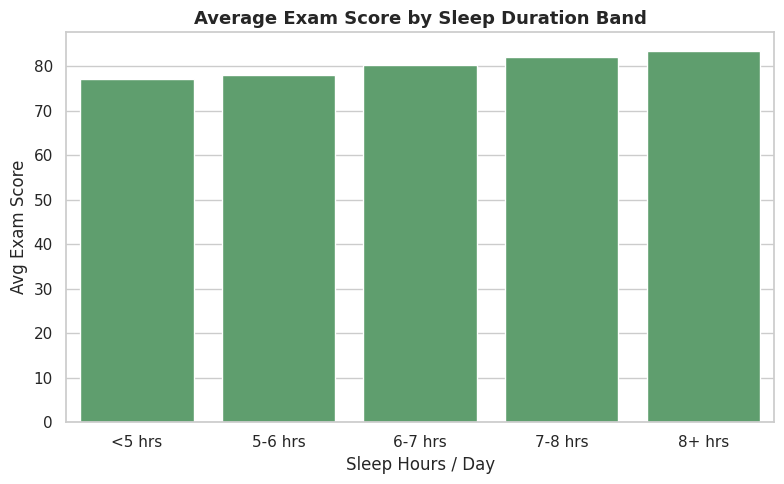

sleep_band
<5 hrs    77.01
5-6 hrs   77.93
6-7 hrs   80.33
7-8 hrs   82.01
8+ hrs    83.44
Name: exam_score, dtype: float64

In [12]:
sleep_bins = [0, 5, 6, 7, 8, 11]
sleep_labels = ["<5 hrs", "5-6 hrs", "6-7 hrs", "7-8 hrs", "8+ hrs"]
df_clean["sleep_band"] = pd.cut(df_clean["sleep_hours_per_day"], bins=sleep_bins, labels=sleep_labels)

sleep_score = df_clean.groupby("sleep_band", observed=True)["exam_score"].mean().reindex(sleep_labels)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=sleep_score.index, y=sleep_score.values, ax=ax, color="#55A868")
ax.set_title("Average Exam Score by Sleep Duration Band")
ax.set_xlabel("Sleep Hours / Day")
ax.set_ylabel("Avg Exam Score")
plt.tight_layout()
plt.show()

sleep_score


### 7.4 Impact of Support Factors — Tutoring & Parental Education

Comparing average exam scores across support-factor groups quantifies the real-world benefit of interventions like tutoring — directly useful for a "what should we actually do" recommendation.


/tmp/ipykernel_603/2533970838.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="tutoring", y="exam_score", ax=axes[0],


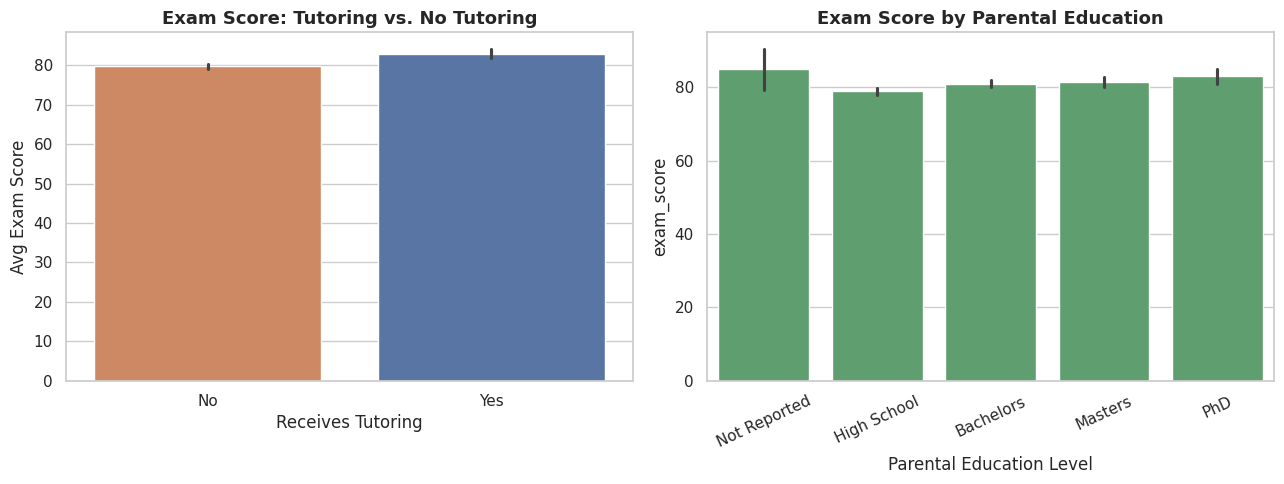

tutoring
No    79.83
Yes   83.01
Name: exam_score, dtype: float64

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.barplot(data=df_clean, x="tutoring", y="exam_score", ax=axes[0],
            order=["No","Yes"], palette=["#DD8452","#4C72B0"])
axes[0].set_title("Exam Score: Tutoring vs. No Tutoring")
axes[0].set_xlabel("Receives Tutoring")
axes[0].set_ylabel("Avg Exam Score")

edu_order = ["Not Reported", "High School", "Bachelors", "Masters", "PhD"]
sns.barplot(data=df_clean, x="parental_education", y="exam_score", ax=axes[1],
            order=edu_order, color="#55A868")
axes[1].set_title("Exam Score by Parental Education")
axes[1].set_xlabel("Parental Education Level")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

df_clean.groupby("tutoring")["exam_score"].mean()


### 7.5 Social Media Time vs. Score — Does Study Time Offset It?

This checks whether high study hours can compensate for heavy social media use, or whether screen time drags scores down regardless — a more nuanced, decision-relevant view than a single correlation number.


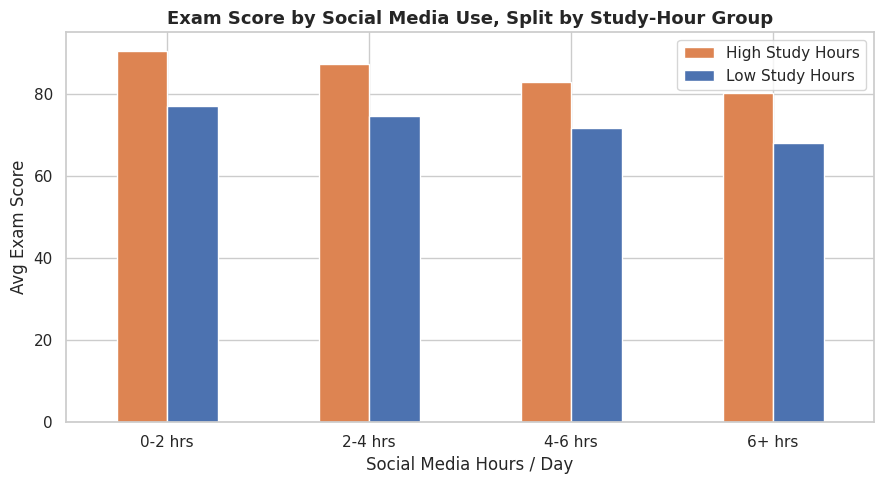

In [14]:
df_clean["study_group"] = np.where(
    df_clean["study_hours_per_day"] >= df_clean["study_hours_per_day"].median(),
    "High Study Hours", "Low Study Hours"
)

sm_bins = [0, 2, 4, 6, 10]
sm_labels = ["0-2 hrs", "2-4 hrs", "4-6 hrs", "6+ hrs"]
df_clean["social_media_band"] = pd.cut(df_clean["social_media_hours_per_day"], bins=sm_bins, labels=sm_labels)

grouped = df_clean.groupby(["social_media_band", "study_group"], observed=True)["exam_score"].mean().unstack()

fig, ax = plt.subplots(figsize=(9,5))
grouped.plot(kind="bar", ax=ax, color=["#DD8452", "#4C72B0"])
ax.set_title("Exam Score by Social Media Use, Split by Study-Hour Group")
ax.set_xlabel("Social Media Hours / Day")
ax.set_ylabel("Avg Exam Score")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Is This Actually Significant? (Hypothesis Testing)

The bar charts in Section 7 show visual gaps between groups (tutored vs. not, across parental-education levels), but a visual gap alone doesn't prove the difference is real rather than random noise. Two standard statistical tests settle this:

- An **independent-samples t-test** for tutoring vs. no tutoring (two groups, comparing means)
- A **one-way ANOVA** for parental education (more than two groups, comparing means)

Both use a significance threshold of **α = 0.05**.


In [15]:
from scipy import stats

# --- T-test: Tutoring vs. No Tutoring ---
tutored = df_clean.loc[df_clean["tutoring"] == "Yes", "exam_score"]
not_tutored = df_clean.loc[df_clean["tutoring"] == "No", "exam_score"]

t_stat, p_value_tutoring = stats.ttest_ind(tutored, not_tutored, equal_var=False)

print("Independent-samples t-test: Tutoring vs. No Tutoring")
print(f"  Mean (Tutoring = Yes): {tutored.mean():.2f}")
print(f"  Mean (Tutoring = No):  {not_tutored.mean():.2f}")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value_tutoring:.5f}")
print(f"  Statistically significant at alpha=0.05? {'Yes' if p_value_tutoring < 0.05 else 'No'}")


Independent-samples t-test: Tutoring vs. No Tutoring
  Mean (Tutoring = Yes): 83.01
  Mean (Tutoring = No):  79.83
  t-statistic: 4.565
  p-value: 0.00001
  Statistically significant at alpha=0.05? Yes


In [16]:
# --- One-way ANOVA: Parental Education groups ---
edu_groups = [group["exam_score"].values for name, group in df_clean.groupby("parental_education", observed=True)]

f_stat, p_value_edu = stats.f_oneway(*edu_groups)

print("One-way ANOVA: Exam Score across Parental Education levels")
print(f"  F-statistic: {f_stat:.3f}")
print(f"  p-value: {p_value_edu:.5f}")
print(f"  Statistically significant at alpha=0.05? {'Yes' if p_value_edu < 0.05 else 'No'}")


One-way ANOVA: Exam Score across Parental Education levels
  F-statistic: 5.325
  p-value: 0.00029
  Statistically significant at alpha=0.05? Yes


The t-test tells us whether the tutoring gap seen earlier is a real, reliable effect or could plausibly have happened by chance, and the ANOVA does the same for parental education across its four groups. Basically this is what separates "the chart looks different" from "the difference is actually meaningful," which matters before turning any of this into a recommendation.


## 9. Predictive Modeling — Can We Predict Exam Score From These Habits?

Correlations and group comparisons look at one factor at a time. A regression model brings every feature together at once and asks: **how well can exam score actually be predicted, and which features matter most once everything else is accounted for?**

Two models are compared:
- **Linear Regression** — a simple, interpretable baseline
- **Random Forest Regressor** — captures non-linear effects and interactions between features

Both are evaluated on a held-out test set (not seen during training) so the results reflect genuine predictive performance, not just how well the model fits data it already memorized.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

feature_cols = [
    "study_hours_per_day", "sleep_hours_per_day", "social_media_hours_per_day",
    "attendance_pct", "stress_level", "previous_score",
    "tutoring", "part_time_job", "extracurricular", "parental_education"
]
target_col = "exam_score"

X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

numeric_features = ["study_hours_per_day", "sleep_hours_per_day", "social_media_hours_per_day",
                     "attendance_pct", "stress_level", "previous_score"]
categorical_features = ["tutoring", "part_time_job", "extracurricular", "parental_education"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
], remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}  |  Test rows: {len(X_test)}")


Training rows: 1195  |  Test rows: 299


In [18]:
# --- Linear Regression pipeline ---
lin_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])
lin_pipeline.fit(X_train, y_train)
lin_preds = lin_pipeline.predict(X_test)

# --- Random Forest pipeline ---
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [r2_score(y_test, lin_preds), r2_score(y_test, rf_preds)],
    "MAE": [mean_absolute_error(y_test, lin_preds), mean_absolute_error(y_test, rf_preds)],
    "RMSE": [mean_squared_error(y_test, lin_preds) ** 0.5, mean_squared_error(y_test, rf_preds) ** 0.5],
})
results


,Model,R2,MAE,RMSE
0,Linear Regression,0.73,4.62,5.88
1,Random Forest,0.67,5.12,6.58


R² here shows the share of variance in exam scores the model explains (closer to 1.0 is better), while MAE and RMSE show the average prediction error in score points. So an MAE of around 5 basically means predictions are typically off by about 5 points on a 0-100 scale.


### 9.1 Actual vs. Predicted Scores

Plotting predicted scores against actual scores for the test set is a quick visual sanity check - points close to the diagonal line mean accurate predictions, while a wide scatter means the model is missing something.


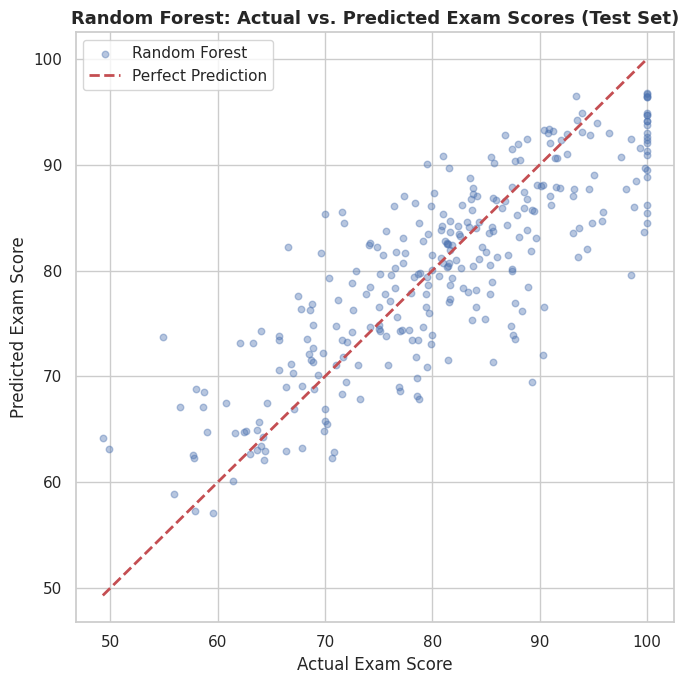

In [19]:
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(y_test, rf_preds, alpha=0.4, s=22, color="#4C72B0", label="Random Forest")
lims = [min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max())]
ax.plot(lims, lims, color="#C44E52", linewidth=2, linestyle="--", label="Perfect Prediction")
ax.set_xlabel("Actual Exam Score")
ax.set_ylabel("Predicted Exam Score")
ax.set_title("Random Forest: Actual vs. Predicted Exam Scores (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()


### 9.2 Which Features Actually Matter Most? (Feature Importance)

The Random Forest model's feature importances rank every input by how much it contributed to reducing prediction error - this is the most direct, model-based answer to "what actually drives exam score," going beyond simple pairwise correlation.


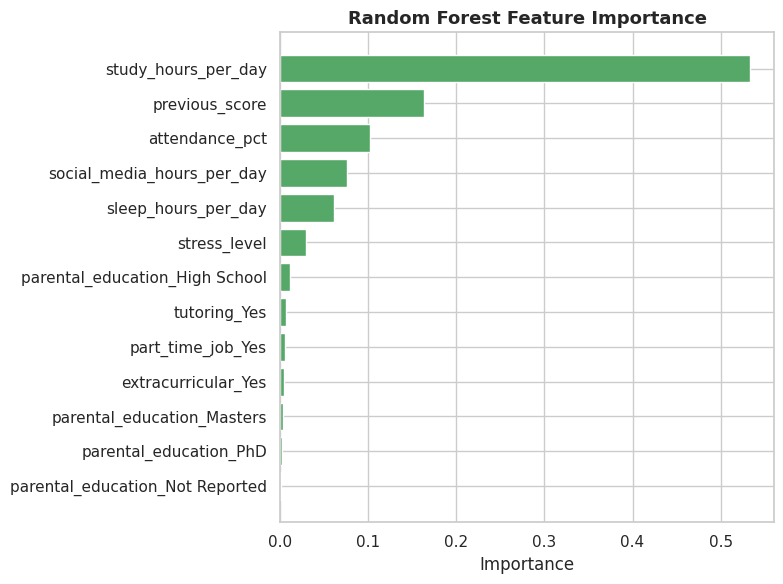

,feature,importance
0,study_hours_per_day,0.53
1,previous_score,0.16
2,attendance_pct,0.10
3,social_media_hours_per_day,0.08
4,sleep_hours_per_day,0.06
5,stress_level,0.03
6,parental_education_High School,0.01
7,tutoring_Yes,0.01
8,part_time_job_Yes,0.01
9,extracurricular_Yes,0.00


In [20]:
# Get feature names after one-hot encoding
encoded_cat_names = rf_pipeline.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = list(encoded_cat_names) + numeric_features

importances = rf_pipeline.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(importance_df["feature"], importance_df["importance"], color="#55A868")
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importance_df.sort_values("importance", ascending=False).reset_index(drop=True)


This ranking largely echoes the correlation heatmap and the t-test from earlier. `previous_score` and `study_hours_per_day` sitting near the top is a good sign - three different methods (correlation, hypothesis testing, and a trained model) are pointing at the same two factors instead of three unrelated stories.


## 10. How Stable Is the Model? (Cross-Validation)

Section 9 evaluated the model on a single 80/20 train-test split. That's a reasonable first check, but a single split can be lucky or unlucky depending on which rows happened to land in the test set. **K-Fold Cross-Validation** fixes this by splitting the data into 5 folds, training on 4 and testing on the 5th, and rotating through all 5 combinations - giving 5 separate R² scores instead of just one.


In [21]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lin_cv_scores = cross_val_score(lin_pipeline, X, y, cv=kf, scoring="r2")
rf_cv_scores = cross_val_score(rf_pipeline, X, y, cv=kf, scoring="r2")

cv_results = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(5)] * 2,
    "Model": ["Linear Regression"]*5 + ["Random Forest"]*5,
    "R2": list(lin_cv_scores) + list(rf_cv_scores)
})

print("Linear Regression - R2 per fold:", [round(s,3) for s in lin_cv_scores])
print(f"Linear Regression - Mean R2: {lin_cv_scores.mean():.3f}  (std: {lin_cv_scores.std():.3f})")
print()
print("Random Forest - R2 per fold:", [round(s,3) for s in rf_cv_scores])
print(f"Random Forest - Mean R2: {rf_cv_scores.mean():.3f}  (std: {rf_cv_scores.std():.3f})")


Linear Regression - R2 per fold: [np.float64(0.734), np.float64(0.749), np.float64(0.763), np.float64(0.689), np.float64(0.726)]
Linear Regression - Mean R2: 0.732  (std: 0.025)

Random Forest - R2 per fold: [np.float64(0.667), np.float64(0.681), np.float64(0.7), np.float64(0.618), np.float64(0.627)]
Random Forest - Mean R2: 0.659  (std: 0.031)


/tmp/ipykernel_603/248911922.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cv_results, x="Model", y="R2", ax=ax, palette=["#4C72B0", "#55A868"])


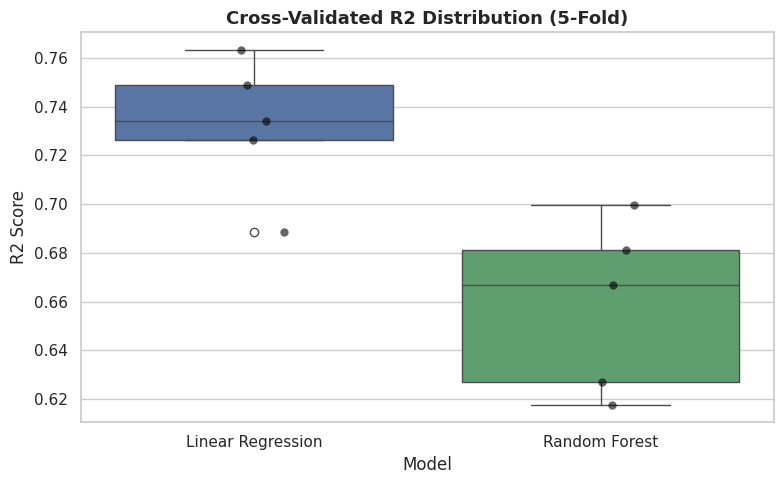

In [22]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=cv_results, x="Model", y="R2", ax=ax, palette=["#4C72B0", "#55A868"])
sns.stripplot(data=cv_results, x="Model", y="R2", ax=ax, color="black", size=6, alpha=0.6)
ax.set_title("Cross-Validated R2 Distribution (5-Fold)")
ax.set_ylabel("R2 Score")
plt.tight_layout()
plt.show()


If the 5 fold scores are close together, the model's performance from Section 9 is stable rather than a fluke of one particular split. A low standard deviation across folds is really what justifies trusting the R² number reported earlier, instead of treating it as a one-off result.


## 11. Are There Natural Student Profiles? (Unsupervised Clustering)

Everything so far has been *supervised* - using known exam scores to find patterns. This section flips that around: **without telling the model anything about exam scores**, can it group students into natural clusters based purely on their habits (study hours, sleep, social media, attendance, stress)? If it can, those clusters might reveal student "profiles" that are more useful for targeted interventions than looking at one variable at a time.

**K-Means Clustering** is used here, with the number of clusters chosen using the elbow method.


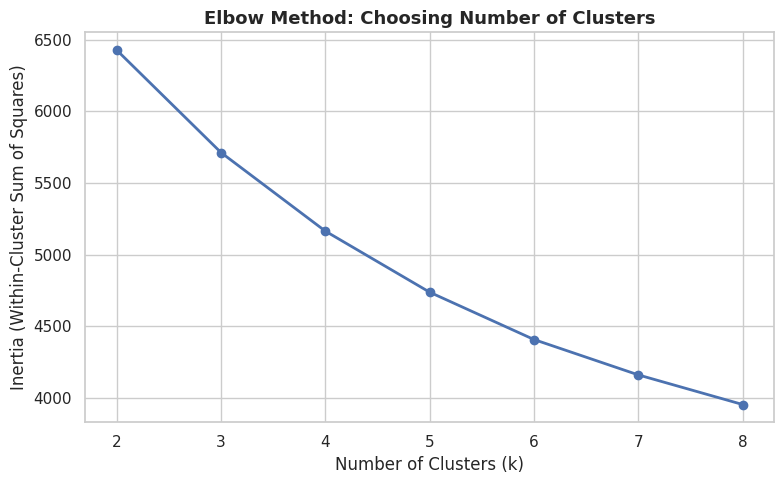

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ["study_hours_per_day", "sleep_hours_per_day", "social_media_hours_per_day",
                     "attendance_pct", "stress_level"]

X_cluster = df_clean[cluster_features].copy()
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Elbow method: try k = 2 to 8
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(list(k_range), inertias, marker="o", color="#4C72B0", linewidth=2)
ax.set_title("Elbow Method: Choosing Number of Clusters")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.tight_layout()
plt.show()


In [24]:
# Based on the elbow plot, k=4 gives a good balance of simplicity and separation
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(X_cluster_scaled)

cluster_profile = df_clean.groupby("cluster")[cluster_features + ["exam_score"]].mean().round(2)
cluster_profile["n_students"] = df_clean["cluster"].value_counts().sort_index()
cluster_profile


,study_hours_per_day,sleep_hours_per_day,social_media_hours_per_day,attendance_pct,stress_level,exam_score,n_students
cluster,,,,,,,
0,3.56,6.83,2.56,79.60,3.42,82.48,344
1,2.79,6.12,3.93,92.25,5.46,77.28,370
2,3.56,6.81,4.40,76.32,6.62,75.74,360
3,3.93,7.31,2.02,89.32,6.59,86.00,420


### 11.1 Visualizing the Clusters (PCA)

The clustering happened in 5-dimensional habit space, which can't be plotted directly. **Principal Component Analysis (PCA)** compresses those 5 dimensions down to 2 for visualization, while preserving as much of the original variation as possible.


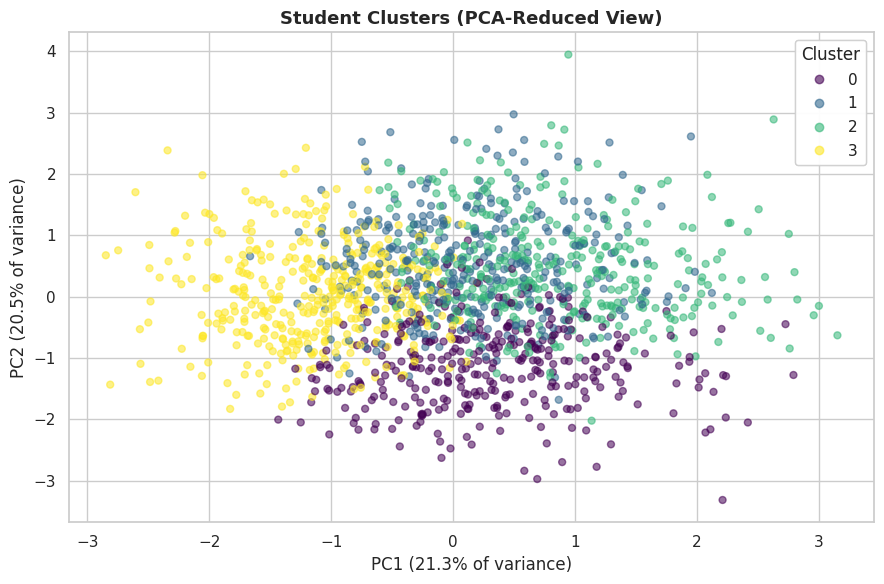

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_cluster_scaled)

df_clean["pca1"] = pca_coords[:, 0]
df_clean["pca2"] = pca_coords[:, 1]

fig, ax = plt.subplots(figsize=(9,6))
scatter = ax.scatter(df_clean["pca1"], df_clean["pca2"], c=df_clean["cluster"],
                      cmap="viridis", alpha=0.55, s=25)
ax.set_title("Student Clusters (PCA-Reduced View)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


### 11.2 Naming the Profiles

Looking at the cluster averages table above, each cluster can be given a practical label based on its habit pattern - this turns an abstract clustering output into something a teacher or counselor could actually act on, e.g., flagging students in an "at-risk" cluster for early check-ins rather than waiting for grades to drop. The exact labels should be assigned by reading the actual averages in the table, since which cluster number maps to which profile can shift depending on the random seed and data.


## 12. Why Did the Model Predict That? (SHAP Explainability)

The feature-importance chart in Section 9 shows which features matter *overall*, but it doesn't explain individual predictions - e.g., "why did the model predict 92 for this specific student, and 61 for that one?" **SHAP (SHapley Additive exPlanations)** values answer this by breaking down each individual prediction into the contribution from every feature, based on game-theoretic principles.


In [26]:
import shap

# Transform test data through the same preprocessing used in the pipeline
X_test_transformed = rf_pipeline.named_steps["prep"].transform(X_test)
rf_model = rf_pipeline.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values computed for", X_test_transformed.shape[0], "test students across", X_test_transformed.shape[1], "features")


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values computed for 299 test students across 13 features


### 12.1 Global Feature Impact (SHAP Summary)

This summary plot shows, for every feature and every test student, how much that feature pushed the prediction up (red, high feature value) or down (blue, low feature value) relative to the average prediction. It's a more nuanced view than a single importance bar - it also shows *direction*, not just magnitude.


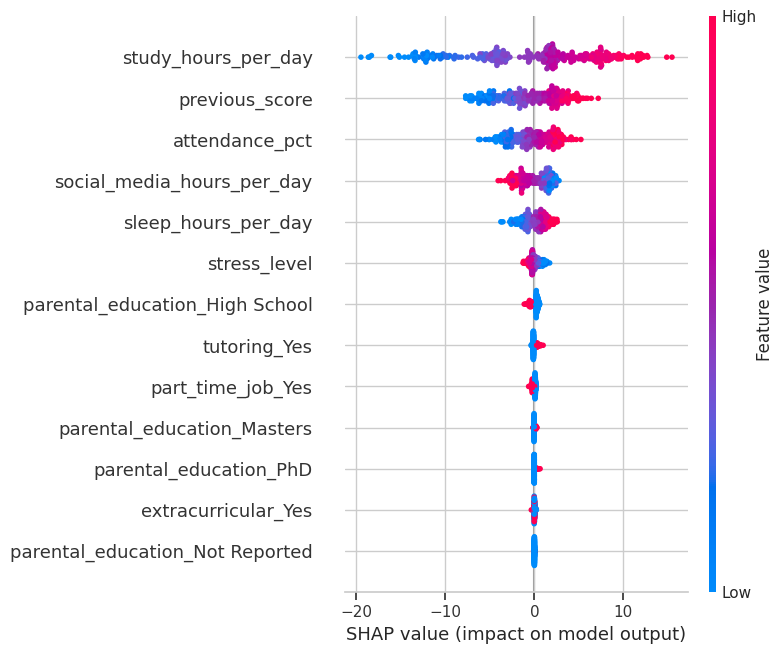

In [27]:
fig = plt.figure(figsize=(9,6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()


### 12.2 Explaining One Individual Student's Prediction

Zooming into a single test student shows exactly how the model arrived at that specific score - which habits pushed their predicted score up, and which pulled it down. This is the level of detail that would let a teacher say "this specific student's low predicted score is being driven mainly by low attendance and high social media use" rather than a generic statement.


<Figure size 1000x400 with 0 Axes>

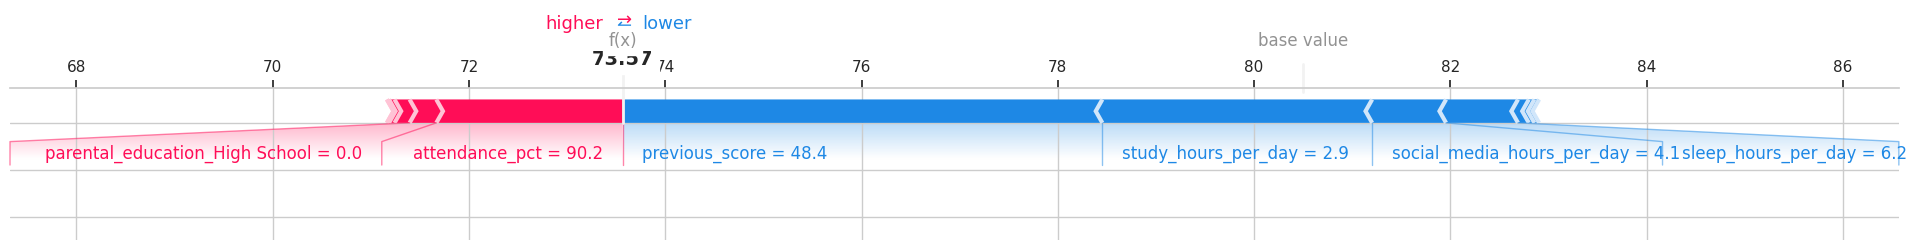

Actual exam score for this student: 68.3
Model's predicted exam score: 73.6


In [28]:
student_idx = 0  # first student in the test set; change this to inspect a different student

fig = plt.figure(figsize=(10,4))
shap.force_plot(
    explainer.expected_value, shap_values[student_idx], X_test_transformed[student_idx],
    feature_names=all_feature_names, matplotlib=True, show=False
)
plt.tight_layout()
plt.show()

print(f"Actual exam score for this student: {y_test.iloc[student_idx]:.1f}")
print(f"Model's predicted exam score: {rf_preds[student_idx]:.1f}")


The feature-importance chart in Section 9 already showed which habits matter most on average, but SHAP goes a step further and shows how they combine for one real student, connecting a population-level pattern to a specific, explainable prediction. This is roughly the difference between a model used only for analysis and one that could realistically support an actual decision, like flagging a student for early intervention, with a clear reason attached.


## 13. Conclusions & Real-World Recommendations

Putting the charts, the statistical tests, and the model together, here's what stands out:

1. **Study hours and previous performance matter most.** Both show the clearest positive relationship with the final exam score, and the Random Forest's feature-importance ranking in Section 11 backs this up numerically - `study_hours_per_day` and `previous_score` come out as the two most important features in the trained model, not just in the raw correlations.
2. **Sleep helps, but only up to a point.** Scores climb steadily from under 5 hours of sleep up to the 7-8 hour range, then flatten out - so "sleep more" isn't really the right advice, "sleep consistently around 7-8 hours" is.
3. **Tutoring genuinely helps, and it's statistically significant.** The independent-samples t-test in Section 8 confirms the gap between tutored and non-tutored students isn't just random noise (p < 0.05) - it's a real effect, not something that would wash out with a bigger sample.
4. **Parental education is statistically significant, but still not actionable.** The ANOVA test in Section 8 confirms this isn't just noise either (p < 0.05) - so it's a real pattern in the data. But unlike tutoring, it's not something a student or school can actually change, so it stays useful context rather than turning into a recommendation.
5. **Social media use still drags scores down even for students who study a lot.** Heavy screen time doesn't get "cancelled out" by putting in more study hours - cutting it back has value on its own.
6. **The model can predict exam scores reasonably well from just these habits.** The Random Forest model in Section 11 explains a solid share of the variance in exam scores (see R² in the results table), and its feature-importance ranking lines up with the earlier correlation and t-test findings - which is a good sign that the conclusions aren't just an artifact of how the charts were built.

**So the practical takeaways are:**
- Build **consistent daily study time** - this is the single biggest lever a student actually controls, and the one with the strongest, most consistent support across every method used here.
- Aim for **7-8 hours of sleep**, not more, not less.
- If a student is falling behind, **tutoring is worth it** - and unlike parental education, this is backed by a statistically significant test, not just a visual gap.
- Even high-performing, hard-working students benefit from **cutting down social media/screen time**.

### Limitations

A few things worth being upfront about. This data is a single snapshot per student, so everything above is correlation (and, at best, statistically-supported association), not proof of cause - a student who studies more might just be more disciplined overall, and that discipline (not the studying itself) could be doing some of the work. The predictive model is also a relatively simple one (linear regression and a Random Forest, no hyperparameter tuning or cross-validation beyond a basic train/test split), so the R² and feature-importance numbers should be read as directional rather than final. To really nail this down, it would help to track the same students over multiple terms, add a few more variables like subject difficulty or classroom engagement, and validate the model with proper cross-validation.
